1. Загружаем две исходные таблицы:
   - `output_files.csv` — файлы, связанные с исправлениями уязвимостей;
   - `output_files_norm.csv` — файлы без такой разметки.
2. Формируем единую таблицу с меткой класса.
3. Проводим предварительную очистку и анализ.
4. Строим базовые признаки по метаданным файла.


In [1]:
import os
import re
import ast
import math
import time
import json
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report


In [2]:
BASE_DIR = Path(".")
VULN_CSV = BASE_DIR / "output_files.csv"
NORM_CSV = BASE_DIR / "output_files_norm.csv"

DATA_DIR = BASE_DIR / "data_generated"
RAW_CACHE_DIR = DATA_DIR / "raw_cache"
DATA_DIR.mkdir(exist_ok=True)
RAW_CACHE_DIR.mkdir(exist_ok=True)

VULN_CSV, NORM_CSV

(WindowsPath('output_files.csv'), WindowsPath('output_files_norm.csv'))

In [3]:
df_vuln = pd.read_csv(VULN_CSV)
df_norm = pd.read_csv(NORM_CSV)

print("vulnerable shape:", df_vuln.shape)
print("normal shape    :", df_norm.shape)

print(df_vuln.head(3))
print(df_norm.head(3))

vulnerable shape: (3851, 6)
normal shape    : (4279, 6)
     owner     repo                           vulnerable_hash  \
0  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
1  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
2  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   

                  file_name  \
0   internal/graph/check.go   
1  internal/graph/errors.go   
2  internal/graph/lookup.go   

                                             raw_url  \
0  https://github.com/authzed/spicedb/raw/15bba2e...   
1  https://github.com/authzed/spicedb/raw/15bba2e...   
2  https://github.com/authzed/spicedb/raw/15bba2e...   

                                        patch_signif  
0                              ['@@ -45,7 +45,9 @@']  
1                           ['@@ -122,3 +122,15 @@']  
2  ['@@ -46,6 +47,10 @@', '@@ -115,9 +120,7 @@', ...  
     owner        repo                           vulnerable_hash  \
0  avelino  awesome-go  470fa1554300d2afaa99b

In [4]:
print("VULN columns:", list(df_vuln.columns))
print("NORM columns:", list(df_norm.columns))
print("Columns equal:", list(df_vuln.columns) == list(df_norm.columns))

VULN columns: ['owner', 'repo', 'vulnerable_hash', 'file_name', 'raw_url', 'patch_signif']
NORM columns: ['owner', 'repo', 'vulnerable_hash', 'file_name', 'raw_url', 'patch_signif']
Columns equal: True


In [5]:
df_vuln = df_vuln.copy()
df_norm = df_norm.copy()

df_vuln["label"] = 1
df_vuln["dataset_source"] = "vulnerable"

df_norm["label"] = 0
df_norm["dataset_source"] = "normal"

df = pd.concat([df_vuln, df_norm], ignore_index=True)

print(df.shape)
print(df.head())

(8130, 8)
     owner     repo                           vulnerable_hash  \
0  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
1  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
2  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
3  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
4  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   

                                  file_name  \
0                   internal/graph/check.go   
1                  internal/graph/errors.go   
2                  internal/graph/lookup.go   
3       internal/membership/foundsubject.go   
4  internal/membership/foundsubject_test.go   

                                             raw_url  \
0  https://github.com/authzed/spicedb/raw/15bba2e...   
1  https://github.com/authzed/spicedb/raw/15bba2e...   
2  https://github.com/authzed/spicedb/raw/15bba2e...   
3  https://github.com/authzed/spicedb/raw/15bba2e...   
4  https://github.com/authzed/spiced

In [6]:
# Предобработка: парсинг patch_signif
def safe_parse_patch_signif(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

df["patch_signif_list"] = df["patch_signif"].apply(safe_parse_patch_signif)
df["patch_count"] = df["patch_signif_list"].apply(len)

print(df[["patch_signif", "patch_signif_list", "patch_count"]].head())

                                        patch_signif  \
0                              ['@@ -45,7 +45,9 @@']   
1                           ['@@ -122,3 +122,15 @@']   
2  ['@@ -46,6 +47,10 @@', '@@ -115,9 +120,7 @@', ...   
3                              ['@@ -0,0 +1,142 @@']   
4                               ['@@ -0,0 +1,62 @@']   

                                   patch_signif_list  patch_count  
0                                [@@ -45,7 +45,9 @@]            1  
1                             [@@ -122,3 +122,15 @@]            1  
2  [@@ -46,6 +47,10 @@, @@ -115,9 +120,7 @@, @@ -...            3  
3                                [@@ -0,0 +1,142 @@]            1  
4                                 [@@ -0,0 +1,62 @@]            1  


In [7]:
print("Пропуски:")
display(df.isna().sum().sort_values(ascending=False))

duplicate_mask = df.duplicated(subset=["owner", "repo", "vulnerable_hash", "file_name", "raw_url", "label"])
print("Число полных дубликатов:", int(duplicate_mask.sum()))

print("\nРаспределение классов:")
print(df["label"].value_counts(dropna=False))
print((df["label"].value_counts(normalize=True) * 100).round(2))

Пропуски:


owner                0
repo                 0
vulnerable_hash      0
file_name            0
raw_url              0
patch_signif         0
label                0
dataset_source       0
patch_signif_list    0
patch_count          0
dtype: int64

Число полных дубликатов: 298

Распределение классов:
label
0    4279
1    3851
Name: count, dtype: int64
label
0    52.63
1    47.37
Name: proportion, dtype: float64


In [8]:
# Удаляем дупликаты
df["row_key"] = df[["owner", "repo", "vulnerable_hash", "file_name", "raw_url", "label"]].astype(str).agg("||".join, axis=1)
df["is_exact_duplicate"] = df.duplicated("row_key", keep=False).astype(int)

before = len(df)
df = df.drop_duplicates("row_key").copy()
after = len(df)

print("До удаления дублей :", before)
print("После удаления      :", after)
print("Удалено             :", before - after)

До удаления дублей : 8130
После удаления      : 7832
Удалено             : 298


In [9]:
df["repo_key"] = df["owner"].astype(str) + "/" + df["repo"].astype(str)
df["extension"] = df["file_name"].str.extract(r"(\.[A-Za-z0-9_+-]+)$", expand=False).fillna("")

summary = {
    "rows": len(df),
    "unique_owners": df["owner"].nunique(),
    "unique_repos": df["repo_key"].nunique(),
    "unique_files": df["file_name"].nunique(),
    "unique_fix_hashes": df["vulnerable_hash"].nunique(),
    "positive_ratio": round(df["label"].mean(), 4),
}

summary

{'rows': 7832,
 'unique_owners': 284,
 'unique_repos': 354,
 'unique_files': 6294,
 'unique_fix_hashes': 1605,
 'positive_ratio': 0.4537}

In [10]:
print(df["extension"].value_counts().head(20))

top_repos = df["repo_key"].value_counts().head(20)
print(top_repos)

extension
.go    7832
Name: count, dtype: int64
repo_key
rancher/rancher             543
jesseduffield/lazydocker    314
kubernetes/kubernetes       246
go-gitea/gitea              152
opentofu/opentofu           150
fatedier/frp                140
ollama/ollama               135
XTLS/Xray-core              134
nats-io/nats-server         134
prometheus/prometheus       121
istio/istio                 118
AdguardTeam/AdGuardHome     111
moby/moby                   109
helm/helm                   108
mattermost/mattermost       103
docker/compose               98
grafana/loki                 97
traefik/traefik              95
gogs/gogs                    92
gohugoio/hugo                89
Name: count, dtype: int64


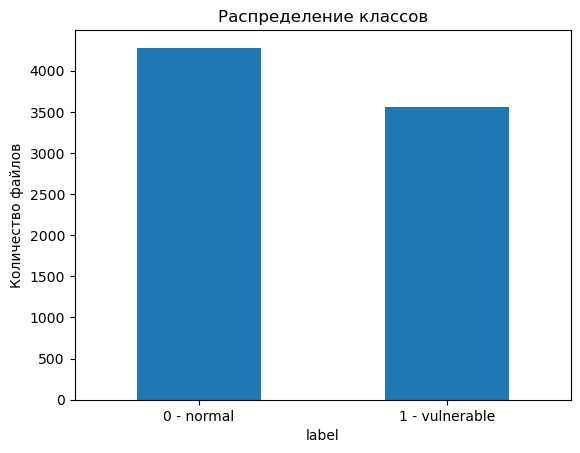

In [11]:
class_counts = df["label"].value_counts().sort_index()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["0 - normal", "1 - vulnerable"], rotation=0)
plt.ylabel("Количество файлов")
plt.title("Распределение классов")
plt.show()

In [12]:

# Формируем метаданные
def build_metadata_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    out["file_basename"] = out["file_name"].str.split("/").str[-1]
    out["dir_path"] = out["file_name"].str.rsplit("/", n=1).str[0]
    out["dir_path"] = out["dir_path"].where(out["dir_path"] != out["file_basename"], "")

    out["path_depth"] = out["file_name"].str.count("/")
    out["path_len"] = out["file_name"].str.len()
    out["filename_len"] = out["file_basename"].str.len()
    out["token_count_in_path"] = out["file_name"].str.count(r"[/_.-]") + 1
    out["raw_url_len"] = out["raw_url"].astype(str).str.len()

    lower_path = out["file_name"].str.lower()

    out["is_test_like"] = lower_path.str.contains(r"(?:^|/)(?:test|tests|testing)(?:/|$)|_test\.|test_", regex=True).astype(int)
    out["is_internal_path"] = lower_path.str.contains(r"(?:^|/)internal(?:/|$)", regex=True).astype(int)
    out["is_pkg_path"] = lower_path.str.contains(r"(?:^|/)pkg(?:/|$)", regex=True).astype(int)
    out["is_cmd_path"] = lower_path.str.contains(r"(?:^|/)cmd(?:/|$)", regex=True).astype(int)

    keyword_patterns = {
        "has_auth_kw": r"auth|login|token|session|permission|acl|rbac",
        "has_crypto_kw": r"crypto|cipher|tls|ssl|x509|jwt|oauth|saml|hash|sign",
        "has_network_kw": r"http|grpc|tcp|udp|socket|proxy|request|server|client",
        "has_storage_kw": r"db|sql|redis|mongo|storage|cache|repo|repository",
        "has_parser_kw": r"parse|parser|decode|encode|marshal|unmarshal|yaml|json|xml",
        "has_input_kw": r"input|user|request|form|query|param|args",
        "has_exec_kw": r"exec|command|shell|os|syscall|runtime",
        "has_security_kw": r"security|vuln|sanitize|escape|csrf|xss|injection|secret",
    }

    for col, pattern in keyword_patterns.items():
        out[col] = lower_path.str.contains(pattern, regex=True).astype(int)

    return out

df_feat = build_metadata_features(df)
print(df_feat.head())


     owner     repo                           vulnerable_hash  \
0  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
1  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
2  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
3  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
4  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   

                                  file_name  \
0                   internal/graph/check.go   
1                  internal/graph/errors.go   
2                  internal/graph/lookup.go   
3       internal/membership/foundsubject.go   
4  internal/membership/foundsubject_test.go   

                                             raw_url  \
0  https://github.com/authzed/spicedb/raw/15bba2e...   
1  https://github.com/authzed/spicedb/raw/15bba2e...   
2  https://github.com/authzed/spicedb/raw/15bba2e...   
3  https://github.com/authzed/spicedb/raw/15bba2e...   
4  https://github.com/authzed/spicedb/raw/15bb

In [13]:
repo_counts = df_feat.groupby("repo_key").size().rename("repo_rows_in_dataset")
owner_counts = df_feat.groupby("owner").size().rename("owner_rows_in_dataset")
fix_counts = df_feat.groupby(["repo_key", "vulnerable_hash"]).size().rename("files_in_same_fix_commit")
dir_counts = df_feat.groupby(["repo_key", "dir_path"]).size().rename("rows_in_same_dir_in_dataset")
file_counts = df_feat.groupby(["repo_key", "file_name"]).size().rename("same_file_occurrences_in_dataset")
repo_pos_ratio = df_feat.groupby("repo_key")["label"].mean().rename("repo_positive_ratio_in_dataset")

df_feat = df_feat.join(repo_counts, on="repo_key")
df_feat = df_feat.join(owner_counts, on="owner")
df_feat = df_feat.join(fix_counts, on=["repo_key", "vulnerable_hash"])
df_feat = df_feat.join(dir_counts, on=["repo_key", "dir_path"])
df_feat = df_feat.join(file_counts, on=["repo_key", "file_name"])
df_feat = df_feat.join(repo_pos_ratio, on="repo_key")

print(df_feat.head())

     owner     repo                           vulnerable_hash  \
0  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
1  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
2  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
3  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   
4  authzed  spicedb  d002401b6b644edd24e8cc63d146d77e6df6a23a   

                                  file_name  \
0                   internal/graph/check.go   
1                  internal/graph/errors.go   
2                  internal/graph/lookup.go   
3       internal/membership/foundsubject.go   
4  internal/membership/foundsubject_test.go   

                                             raw_url  \
0  https://github.com/authzed/spicedb/raw/15bba2e...   
1  https://github.com/authzed/spicedb/raw/15bba2e...   
2  https://github.com/authzed/spicedb/raw/15bba2e...   
3  https://github.com/authzed/spicedb/raw/15bba2e...   
4  https://github.com/authzed/spicedb/raw/15bb

In [14]:

base_feature_columns = [
    "patch_count",
    "path_depth",
    "path_len",
    "filename_len",
    "token_count_in_path",
    "raw_url_len",
    "is_test_like",
    "is_internal_path",
    "is_pkg_path",
    "is_cmd_path",
    "has_auth_kw",
    "has_crypto_kw",
    "has_network_kw",
    "has_storage_kw",
    "has_parser_kw",
    "has_input_kw",
    "has_exec_kw",
    "has_security_kw",
    "repo_rows_in_dataset",
    "owner_rows_in_dataset",
    "files_in_same_fix_commit",
    "rows_in_same_dir_in_dataset",
    "same_file_occurrences_in_dataset",
    "repo_positive_ratio_in_dataset",
]

target_column = "label"

missing_features = [col for col in base_feature_columns if col not in df_feat.columns]
if missing_features:
    raise ValueError(f"Отсутствуют признаки: {missing_features}")

print("Число базовых признаков:", len(base_feature_columns))
print(base_feature_columns)


Число базовых признаков: 24
['patch_count', 'path_depth', 'path_len', 'filename_len', 'token_count_in_path', 'raw_url_len', 'is_test_like', 'is_internal_path', 'is_pkg_path', 'is_cmd_path', 'has_auth_kw', 'has_crypto_kw', 'has_network_kw', 'has_storage_kw', 'has_parser_kw', 'has_input_kw', 'has_exec_kw', 'has_security_kw', 'repo_rows_in_dataset', 'owner_rows_in_dataset', 'files_in_same_fix_commit', 'rows_in_same_dir_in_dataset', 'same_file_occurrences_in_dataset', 'repo_positive_ratio_in_dataset']


In [15]:

df_feat["sample_id"] = df_feat["row_key"].apply(lambda x: hashlib.md5(x.encode("utf-8")).hexdigest()[:12])

base_output_columns = [
    "sample_id",
    "label",
    "dataset_source",
    "owner",
    "repo",
    "repo_key",
    "vulnerable_hash",
    "file_name",
    "raw_url",
    "patch_signif",
] + base_feature_columns

baseline_df = df_feat[base_output_columns].copy()
baseline_path = DATA_DIR / "dataset_baseline_features.csv"
baseline_df.to_csv(baseline_path, index=False)

print("Сохранено:", baseline_path)
print("Число признаков:", len(base_feature_columns))
display(baseline_df.head())


Сохранено: data_generated\dataset_baseline_features.csv
Число признаков: 24


,sample_id,label,dataset_source,owner,repo,repo_key,vulnerable_hash,file_name,raw_url,patch_signif,...,has_parser_kw,has_input_kw,has_exec_kw,has_security_kw,repo_rows_in_dataset,owner_rows_in_dataset,files_in_same_fix_commit,rows_in_same_dir_in_dataset,same_file_occurrences_in_dataset,repo_positive_ratio_in_dataset
0,da774d86f765,1,vulnerable,authzed,spicedb,authzed/spicedb,d002401b6b644edd24e8cc63d146d77e6df6a23a,internal/graph/check.go,https://github.com/authzed/spicedb/raw/15bba2e...,"['@@ -45,7 +45,9 @@']",...,0,0,0,0,28,28,23,5,1,1.0
1,9fad16ac21ae,1,vulnerable,authzed,spicedb,authzed/spicedb,d002401b6b644edd24e8cc63d146d77e6df6a23a,internal/graph/errors.go,https://github.com/authzed/spicedb/raw/15bba2e...,"['@@ -122,3 +122,15 @@']",...,0,0,0,0,28,28,23,5,1,1.0
2,ca9fb44ee741,1,vulnerable,authzed,spicedb,authzed/spicedb,d002401b6b644edd24e8cc63d146d77e6df6a23a,internal/graph/lookup.go,https://github.com/authzed/spicedb/raw/15bba2e...,"['@@ -46,6 +47,10 @@', '@@ -115,9 +120,7 @@', ...",...,0,0,0,0,28,28,23,5,1,1.0
3,d33837a13280,1,vulnerable,authzed,spicedb,authzed/spicedb,d002401b6b644edd24e8cc63d146d77e6df6a23a,internal/membership/foundsubject.go,https://github.com/authzed/spicedb/raw/15bba2e...,"['@@ -0,0 +1,142 @@']",...,0,0,0,0,28,28,23,6,1,1.0
4,9fa4007aa783,1,vulnerable,authzed,spicedb,authzed/spicedb,d002401b6b644edd24e8cc63d146d77e6df6a23a,internal/membership/foundsubject_test.go,https://github.com/authzed/spicedb/raw/15bba2e...,"['@@ -0,0 +1,62 @@']",...,0,0,0,0,28,28,23,6,1,1.0


In [16]:
repo_stats = (
    df_feat.groupby(["owner", "repo"])["label"]
      .agg(total="size", positives="sum")
      .reset_index()
)

repo_stats["negatives"] = repo_stats["total"] - repo_stats["positives"]
repo_stats["positive_rate"] = repo_stats["positives"] / repo_stats["total"]

repo_stats = repo_stats.sort_values(["positives", "negatives", "total"], ascending=False).reset_index(drop=True)
display(repo_stats.head(20))

,owner,repo,total,positives,negatives,positive_rate
0,rancher,rancher,543,543,0,1.000000
1,nats-io,nats-server,134,134,0,1.000000
2,mattermost,mattermost,103,103,0,1.000000
3,kubernetes,kubernetes,246,75,171,0.304878
4,gogo,protobuf,74,74,0,1.000000
5,aws,aws-sdk-go,73,73,0,1.000000
6,argoproj,argo-cd,72,72,0,1.000000
7,moby,moby,109,66,43,0.605505
8,jackc,pgx,65,65,0,1.000000
9,zitadel,zitadel,63,63,0,1.000000


In [17]:

# Автоматический выбор holdout-проекта:
# берём репозиторий, где есть хотя бы 5 уязвимых и 20 обычных файлов.
candidates = repo_stats[(repo_stats["positives"] >= 5) & (repo_stats["negatives"] >= 20)].copy()

if len(candidates) == 0:
    raise ValueError("Не найден репозиторий, подходящий для holdout-проверки.")

# Берём самый крупный подходящий репозиторий
candidates = candidates.sort_values(["positives", "negatives", "total"], ascending=False).reset_index(drop=True)
holdout_owner = candidates.iloc[0]["owner"]
holdout_repo = candidates.iloc[0]["repo"]
holdout_repo_key = f"{holdout_owner}/{holdout_repo}"

print("Выбран новый проект для проверки:")
print(f"owner = {holdout_owner}")
print(f"repo  = {holdout_repo}")
print(f"repo_key = {holdout_repo_key}")


Выбран новый проект для проверки:
owner = kubernetes
repo  = kubernetes
repo_key = kubernetes/kubernetes


In [18]:

# Разделяем данные: выбранный репозиторий идёт только в тест, остальные — в обучение
train_df = df_feat[df_feat["repo_key"] != holdout_repo_key].copy()
df_test = df_feat[df_feat["repo_key"] == holdout_repo_key].copy()

if train_df.empty or df_test.empty:
    raise ValueError("Некорректное разбиение: train_df или df_test пустой.")

X_train = train_df[base_feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = df_test[base_feature_columns].copy()
y_test = df_test[target_column].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print("Test class balance:")
print(y_test.value_counts(normalize=True).sort_index())


Train shape: (7586, 24)
Test shape : (246, 24)
Train class balance:
label
0    0.541524
1    0.458476
Name: proportion, dtype: float64
Test class balance:
label
0    0.695122
1    0.304878
Name: proportion, dtype: float64


In [19]:

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("PR-AUC:", average_precision_score(y_test, test_proba))


ROC-AUC: 0.8473294346978558
PR-AUC: 0.6181531606796169


In [20]:

test_pred = (test_proba >= 0.5).astype(int)

results = df_test[["owner", "repo", "repo_key", "file_name", "vulnerable_hash", "raw_url", "label"]].copy()
results["probability_vulnerability"] = test_proba
results["pred_label_05"] = test_pred
results = results.sort_values("probability_vulnerability", ascending=False).reset_index(drop=True)

display(results.head(20))


,owner,repo,repo_key,file_name,vulnerable_hash,raw_url,label,probability_vulnerability,pred_label_05
0,kubernetes,kubernetes,kubernetes/kubernetes,test/e2e_node/pods_api_test.go,0809c4f37fdca592d9a8efd5e189102ca1082697,https://github.com/kubernetes/kubernetes/raw/6...,0,0.494934,0
1,kubernetes,kubernetes,kubernetes/kubernetes,test/e2e_node/util_kubeletconfig.go,bf1abbf2e987883ffacaaf6f84218bcbfd444876,https://github.com/kubernetes/kubernetes/raw/8...,0,0.406170,0
2,kubernetes,kubernetes,kubernetes/kubernetes,pkg/storage/util.go,3bd855a342a1dc5583dcedc72b6b49f7b369cce7,https://github.com/kubernetes/kubernetes/raw/3...,1,0.397081,0
3,kubernetes,kubernetes,kubernetes/kubernetes,pkg/storage/util.go,054b779cebfa8952abef41048a79ad0cfa3a43ec,https://github.com/kubernetes/kubernetes/raw/6...,1,0.397081,0
4,kubernetes,kubernetes,kubernetes/kubernetes,pkg/credentialprovider/config_test.go,3a42886dee904cbbbbc593705a64501ec3cb76d5,https://github.com/kubernetes/kubernetes/raw/1...,1,0.388501,0
5,kubernetes,kubernetes,kubernetes/kubernetes,pkg/apis/core/types.go,58f1520a03cdb0cc88d7d1be59894c637d7c5537,https://github.com/kubernetes/kubernetes/raw/0...,0,0.378029,0
6,kubernetes,kubernetes,kubernetes/kubernetes,pkg/api/rest/create.go,054b779cebfa8952abef41048a79ad0cfa3a43ec,https://github.com/kubernetes/kubernetes/raw/6...,1,0.359845,0
7,kubernetes,kubernetes,kubernetes/kubernetes,pkg/api/rest/create.go,3bd855a342a1dc5583dcedc72b6b49f7b369cce7,https://github.com/kubernetes/kubernetes/raw/3...,1,0.359845,0
8,kubernetes,kubernetes,kubernetes/kubernetes,pkg/features/kube_features.go,e616858316df68aea76390062becc70957f24f66,https://github.com/kubernetes/kubernetes/raw/5...,1,0.357117,0
9,kubernetes,kubernetes,kubernetes/kubernetes,pkg/features/kube_features.go,a962fa5fc6cad031cc323e8ad74c72231d03e0d2,https://github.com/kubernetes/kubernetes/raw/4...,1,0.357117,0


In [21]:
roc_auc = roc_auc_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan
avg_precision = average_precision_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print()
print("Classification report при пороге 0.5:")
print(classification_report(y_test, test_pred, digits=4))

ROC-AUC: 0.8473
Average Precision: 0.6182

Classification report при пороге 0.5:
              precision    recall  f1-score   support

           0     0.6951    1.0000    0.8201       171
           1     0.0000    0.0000    0.0000        75

    accuracy                         0.6951       246
   macro avg     0.3476    0.5000    0.4101       246
weighted avg     0.4832    0.6951    0.5701       246



C:\Users\ro517\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ro517\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ro517\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
def precision_at_k(y_true, y_score, k):
    tmp = pd.DataFrame({"y_true": y_true, "y_score": y_score}).sort_values("y_score", ascending=False)
    topk = tmp.head(k)
    return topk["y_true"].mean()

def recall_at_k(y_true, y_score, k):
    tmp = pd.DataFrame({"y_true": y_true, "y_score": y_score}).sort_values("y_score", ascending=False)
    topk = tmp.head(k)
    total_pos = tmp["y_true"].sum()
    if total_pos == 0:
        return np.nan
    return topk["y_true"].sum() / total_pos

for k in [5, 10, 20, 30, 50]:
    k_eff = min(k, len(results))
    p_at_k = precision_at_k(y_test.values, test_proba, k_eff)
    r_at_k = recall_at_k(y_test.values, test_proba, k_eff)
    print(f"K={k_eff:>3} | Precision@K={p_at_k:.4f} | Recall@K={r_at_k:.4f}")

K=  5 | Precision@K=0.6000 | Recall@K=0.0400
K= 10 | Precision@K=0.7000 | Recall@K=0.0933
K= 20 | Precision@K=0.6500 | Recall@K=0.1733
K= 30 | Precision@K=0.6333 | Recall@K=0.2533
K= 50 | Precision@K=0.6000 | Recall@K=0.4000


In [23]:
top_n = 20
top_results = results.head(top_n).copy()

print(f"Топ-{top_n} наиболее рискованных файлов:")
display(top_results[["file_name", "probability_vulnerability", "label"]])

top_hits = int(top_results["label"].sum())
top_precision = top_results["label"].mean()

print(f"Число реальных уязвимых файлов в top-{top_n}: {top_hits}")
print(f"Precision@{top_n}: {top_precision:.4f}")


Топ-20 наиболее рискованных файлов:


,file_name,probability_vulnerability,label
0,test/e2e_node/pods_api_test.go,0.494934,0
1,test/e2e_node/util_kubeletconfig.go,0.406170,0
2,pkg/storage/util.go,0.397081,1
3,pkg/storage/util.go,0.397081,1
4,pkg/credentialprovider/config_test.go,0.388501,1
5,pkg/apis/core/types.go,0.378029,0
6,pkg/api/rest/create.go,0.359845,1
7,pkg/api/rest/create.go,0.359845,1
8,pkg/features/kube_features.go,0.357117,1
9,pkg/features/kube_features.go,0.357117,1


Число реальных уязвимых файлов в top-20: 13
Precision@20: 0.6500


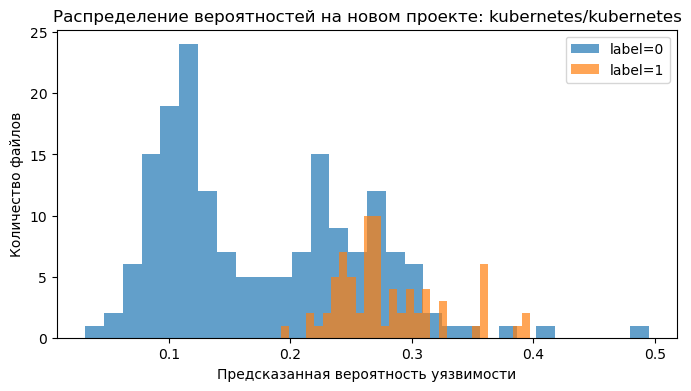

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(results.loc[results["label"] == 0, "probability_vulnerability"], bins=30, alpha=0.7, label="label=0")
plt.hist(results.loc[results["label"] == 1, "probability_vulnerability"], bins=30, alpha=0.7, label="label=1")
plt.title(f"Распределение вероятностей на новом проекте: {holdout_owner}/{holdout_repo}")
plt.xlabel("Предсказанная вероятность уязвимости")
plt.ylabel("Количество файлов")
plt.legend()
plt.show()

,feature,importance
0,repo_positive_ratio_in_dataset,0.605872
1,repo_rows_in_dataset,0.130273
2,owner_rows_in_dataset,0.084552
3,files_in_same_fix_commit,0.044685
4,rows_in_same_dir_in_dataset,0.023957
5,raw_url_len,0.015687
6,path_len,0.015036
7,same_file_occurrences_in_dataset,0.012988
8,path_depth,0.010008
9,token_count_in_path,0.009606


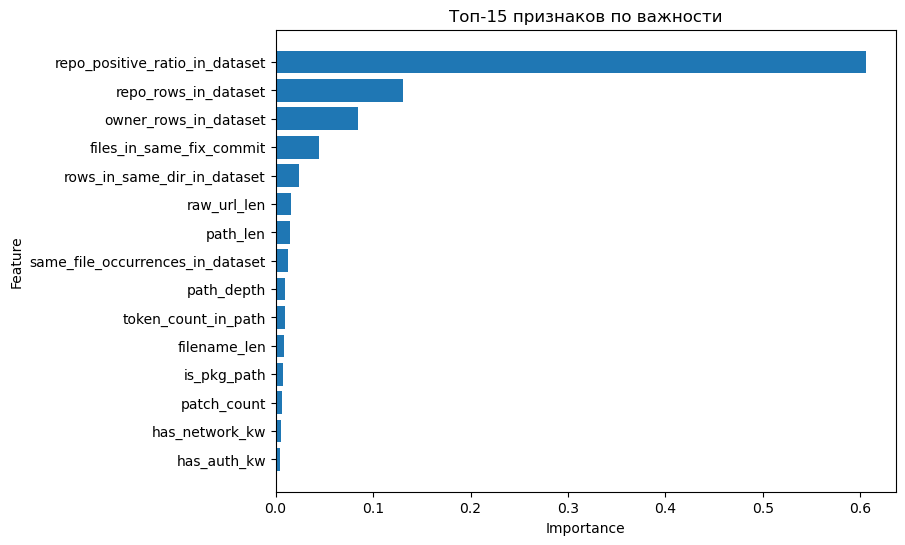

In [25]:
feature_importance = pd.DataFrame({
    "feature": base_feature_columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(feature_importance)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance["feature"].head(15)[::-1], feature_importance["importance"].head(15)[::-1])
plt.title("Топ-15 признаков по важности")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [26]:
OUT_PATH = f"predictions_{holdout_owner}_{holdout_repo}.csv"
results.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("Сохранено:", OUT_PATH)

Сохранено: predictions_kubernetes_kubernetes.csv


In [27]:

from IPython.display import HTML, display

def build_repo_url(row):
    return f"https://github.com/{row['owner']}/{row['repo']}"

def build_file_url(row):
    raw_url = str(row.get("raw_url", "")).strip()
    if raw_url.startswith("https://github.com/") and "/raw/" in raw_url:
        return raw_url.replace("/raw/", "/blob/", 1)
    if raw_url.startswith("https://raw.githubusercontent.com/"):
        parts = raw_url.replace("https://raw.githubusercontent.com/", "").split("/", 3)
        if len(parts) == 4:
            owner, repo, ref, path = parts
            return f"https://github.com/{owner}/{repo}/blob/{ref}/{path}"
    return f"https://github.com/{row['owner']}/{row['repo']}/blob/master/{row['file_name']}"

examples_n = min(10, len(results))
examples = results.head(examples_n).copy()
examples["repo_url"] = examples.apply(build_repo_url, axis=1)
examples["file_url"] = examples.apply(build_file_url, axis=1)
examples["predicted_probability"] = examples["probability_vulnerability"].round(4)

examples["repo_link"] = examples.apply(
    lambda r: f'<a href="{r["repo_url"]}" target="_blank">{r["owner"]}/{r["repo"]}</a>',
    axis=1
)
examples["file_link"] = examples.apply(
    lambda r: f'<a href="{r["file_url"]}" target="_blank">{r["file_name"]}</a>',
    axis=1
)

display(HTML(
    examples[["repo_link", "file_link", "predicted_probability", "label"]].to_html(
        escape=False, index=False
    )
))


repo_link,file_link,predicted_probability,label
kubernetes/kubernetes,test/e2e_node/pods_api_test.go,0.4949,0
kubernetes/kubernetes,test/e2e_node/util_kubeletconfig.go,0.4062,0
kubernetes/kubernetes,pkg/storage/util.go,0.3971,1
kubernetes/kubernetes,pkg/storage/util.go,0.3971,1
kubernetes/kubernetes,pkg/credentialprovider/config_test.go,0.3885,1
kubernetes/kubernetes,pkg/apis/core/types.go,0.3780,0
kubernetes/kubernetes,pkg/api/rest/create.go,0.3598,1
kubernetes/kubernetes,pkg/api/rest/create.go,0.3598,1
kubernetes/kubernetes,pkg/features/kube_features.go,0.3571,1
kubernetes/kubernetes,pkg/features/kube_features.go,0.3571,1
